# Binary MLP Training with PyTorch

This notebook trains a binary multilayer perceptron on the processed student depression dataset.

It connects the preprocessing work from the previous notebook to the optimization stage of the project: we define a model, minimize a loss function, and then check whether the learned parameters generalize outside the training split.

Although a neural network training problem is not convex in the strict mathematical sense, the workflow still reflects the core ideas from convex optimization: objective minimization, regularization, constrained capacity through architecture choices, and validation-based model selection.

In practice, the notebook shows how the data is turned into a trainable format, how the loss and accuracy evolve during optimization, and how the final checkpoint and evaluation summary capture the result of that training run.

In [1]:
# Global setup and reproducibility
from pathlib import Path
import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Robust project root detection: walk ancestors and pick the first directory
# that contains either the processed data file or a README.md (heuristic).
def find_project_root(start: Path = Path.cwd()):
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "data" / "processed" / "clean_student_data.csv").exists():
            return p
        if (p / "README.md").exists():
            return p
    return start

PROJECT_ROOT = find_project_root()

# Backwards-compatible fallback: if executing from a top-level `notebooks` directory
# keep one level up as the project root (legacy behavior).
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Print to confirm where the notebook thinks the repo root is and which device is used.
print(f"Project root: {PROJECT_ROOT}")
print(f"Using device: {device}")

# Training hyperparameters (tweak these as needed)
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 25

# Adam-specific hyperparameters (configurable)

ADAM_BETAS = (0.9, 0.999)
ADAM_EPS = 1e-8
ADAM_AMSGRAD = False

Project root: C:\Users\Elodie\DataspellProjects\Convex-Optimization
Using device: cpu


In [2]:
# Load processed data and convert target to 0/1 for PyTorch
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "clean_student_data.csv"

df = pd.read_csv(DATA_PATH)
if "Depression" not in df.columns:
    raise KeyError("Expected a Depression target column in the processed CSV.")

X = df.drop(columns=["Depression"]).to_numpy(dtype=np.float32)
y = df["Depression"].map({-1: 0, 1: 1}).to_numpy(dtype=np.float32)
feature_names = [col for col in df.columns if col != "Depression"]

print(f"Dataset shape: {df.shape}")
print(f"Feature count: {len(feature_names)}")
print("Class distribution:")
print(pd.Series(y.astype(int)).value_counts().sort_index())
print(df.head())

Dataset shape: (100000, 18)
Feature count: 17
Class distribution:
0    89938
1    10062
Name: count, dtype: int64
        Age      CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  \
0  0.495403  0.772553        0.262011    -0.612083           -0.069468   
1 -0.504411 -0.228120       -0.909858     1.361535            1.679202   
2 -0.504411  0.305063       -0.974962    -1.118139           -1.145572   
3 -0.004504  1.444970        0.265221    -1.269956            0.737610   
4 -1.004318  0.544076       -0.063508    -0.966322            0.535841   

   Physical_Activity  Stress_Level  Transportation_Time  Student_Debt  \
0           0.914222      0.609728             0.480073             0   
1           1.559878     -1.496801            -0.666320             0   
2           1.444582     -0.794625             0.265124             1   
3           1.283168     -0.794625             1.411518             1   
4          -1.622284      1.311904            -0.021474             0   

  

## 2. Train / Validation / Test Split

This split separates model fitting from model selection and final evaluation. The validation set lets us watch what happens while the optimizer is updating the weights, and the test set stays untouched until the end so it can show the final result on unseen data.

From a convex optimization perspective, this is the practical equivalent of checking whether the learned solution is stable outside the samples used to fit it, even though the underlying neural network objective is non-convex.

The next code cell prints the split sizes and class balance, so you can immediately see that the partitions were created correctly and that the target distribution stayed consistent across them.

In [3]:
# Train / validation / test split
from sklearn.model_selection import train_test_split

TEST_RATIO = 0.15
VAL_RATIO = 0.15
RANDOM_STATE = 42

# First split off the test set.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_RATIO,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Split the remaining data into train and validation.
val_size_relative = VAL_RATIO / (1.0 - TEST_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_size_relative,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")
print("\nClass balance:")
print(f"Train: {np.bincount(y_train.astype(int))}")
print(f"Validation: {np.bincount(y_val.astype(int))}")
print(f"Test: {np.bincount(y_test.astype(int))}")

Train shape: (69999, 17)
Validation shape: (15001, 17)
Test shape: (15000, 17)

Class balance:
Train: [62955  7044]
Validation: [13492  1509]
Test: [13491  1509]


## 3. Model and Optimization Setup

The MLP is a compact function approximator with a sigmoid output, so the prediction can be read as a probability of depression.

The loss is binary cross-entropy, which turns the classification task into a differentiable objective that can be minimized by gradient-based optimization. Adam is used here because it combines adaptive step sizes with momentum-like updates, which usually makes training more stable on tabular data.

Dropout and weight decay act as regularization terms in spirit: they reduce the model's capacity to memorize the training set and help the optimization settle on a solution that generalizes better.

The following cell prints the architecture and device, so you can confirm that the model was built with the intended layers and that it is running on CPU or GPU as expected.

In [4]:
# Model definition and loaders
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

class BinaryMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers=(64, 32), dropout=0.0):
        super().__init__()
        layers = []
        layer_sizes = [input_dim, *hidden_layers]

        for in_features, out_features in zip(layer_sizes[:-1], layer_sizes[1:]):
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(layer_sizes[-1], 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)


def make_loader(X_array, y_array, batch_size=128, shuffle=False):
    tensor_X = torch.from_numpy(X_array).float()
    tensor_y = torch.from_numpy(y_array).float()
    dataset = TensorDataset(tensor_X, tensor_y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_loader = make_loader(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

model = BinaryMLP(
    input_dim=X_train.shape[1],
    hidden_layers=(64, 32),
    dropout=0.1,
).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=ADAM_BETAS,
    eps=ADAM_EPS,
    amsgrad=ADAM_AMSGRAD,
)

print(model)
print(f"Using device: {device}")

BinaryMLP(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Using device: cpu


In [5]:
# Training loop

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        probs = model(batch_X)
        loss = criterion(probs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        preds = (probs >= 0.5).long()
        correct += (preds == batch_y.long()).sum().item()
        total += batch_X.size(0)

    return running_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            probs = model(batch_X)
            loss = criterion(probs, batch_y)
            running_loss += loss.item() * batch_X.size(0)
            preds = (probs >= 0.5).long()
            correct += (preds == batch_y.long()).sum().item()
            total += batch_X.size(0)

    return running_loss / total, correct / total

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_loss = float("inf")
best_state = None
patience = 5
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch} epochs.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print("Restored best validation model.")

Epoch 01/25 | train_loss=0.3280 train_acc=0.8992 | val_loss=0.3072 val_acc=0.8994
Epoch 02/25 | train_loss=0.3092 train_acc=0.8993 | val_loss=0.3040 val_acc=0.8994
Epoch 03/25 | train_loss=0.3065 train_acc=0.8994 | val_loss=0.3026 val_acc=0.8992
Epoch 04/25 | train_loss=0.3056 train_acc=0.8994 | val_loss=0.3021 val_acc=0.8996
Epoch 05/25 | train_loss=0.3040 train_acc=0.8995 | val_loss=0.3016 val_acc=0.8991
Epoch 06/25 | train_loss=0.3040 train_acc=0.8994 | val_loss=0.3009 val_acc=0.8993
Epoch 07/25 | train_loss=0.3037 train_acc=0.8991 | val_loss=0.3002 val_acc=0.8991
Epoch 08/25 | train_loss=0.3021 train_acc=0.8992 | val_loss=0.2995 val_acc=0.8991
Epoch 09/25 | train_loss=0.3014 train_acc=0.8996 | val_loss=0.2992 val_acc=0.8993
Epoch 10/25 | train_loss=0.3009 train_acc=0.8992 | val_loss=0.2988 val_acc=0.8995
Epoch 11/25 | train_loss=0.3003 train_acc=0.8994 | val_loss=0.2985 val_acc=0.8993
Epoch 12/25 | train_loss=0.2999 train_acc=0.8990 | val_loss=0.2985 val_acc=0.8989
Epoch 13/25 | tr

## 4. Training and Early Stopping

The training loop tracks both the objective value and accuracy on the training and validation sets. That lets us see not only whether the model is fitting the data, but also whether the validation performance is improving at the same time.

Early stopping is a practical model selection rule: if validation loss stops improving, the current parameters are likely close to the best trade-off between fit and generalization for this architecture. When that happens, the notebook restores the best checkpoint instead of keeping a later, worse one.

The history printed by the loop makes the training dynamics visible epoch by epoch, and the early-stopping message shows the point where the optimization stopped producing a better validation result.

Train metrics: {'loss': 0.2953663564368325, 'accuracy': 0.8995128501835741}
Validation metrics: {'loss': 0.2969859322800842, 'accuracy': 0.8992067195520299}
Test metrics: {'loss': 0.2981799572308858, 'accuracy': 0.8992}

Test classification report:
               precision    recall  f1-score   support

No Depression       0.90      1.00      0.95     13491
   Depression       0.42      0.01      0.01      1509

     accuracy                           0.90     15000
    macro avg       0.66      0.50      0.48     15000
 weighted avg       0.85      0.90      0.85     15000



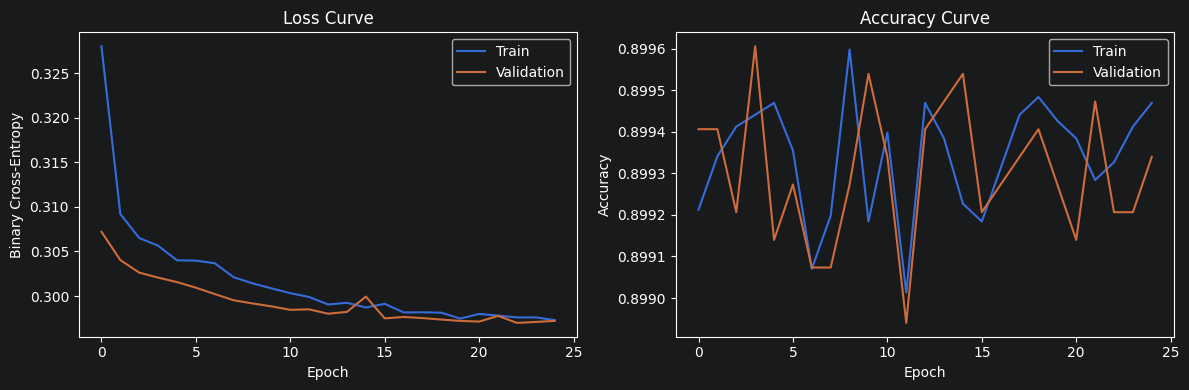

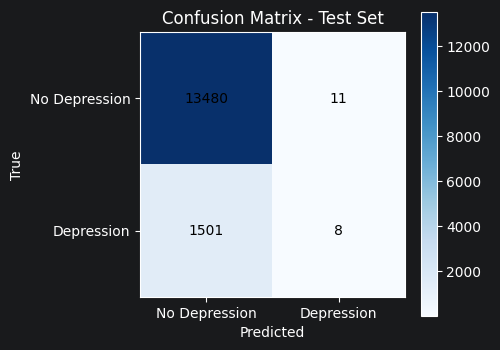

Displayed plots and metrics in the notebook.


In [6]:
# Evaluation and visualizations

def evaluate_split(model, loader):
    model.eval()
    all_probs = []
    all_preds = []
    all_targets = []
    total_loss = 0.0
    criterion = nn.BCELoss()

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            probs = model(batch_X)
            loss = criterion(probs, batch_y)
            total_loss += loss.item() * batch_X.size(0)
            all_probs.append(probs.cpu().numpy())
            all_preds.append((probs >= 0.5).long().cpu().numpy())
            all_targets.append(batch_y.long().cpu().numpy())

    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(y_true, y_pred)
    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

train_eval = evaluate_split(model, train_loader)
val_eval = evaluate_split(model, val_loader)
test_eval = evaluate_split(model, test_loader)

print("Train metrics:", {k: v for k, v in train_eval.items() if k not in {"y_true", "y_pred", "y_prob"}})
print("Validation metrics:", {k: v for k, v in val_eval.items() if k not in {"y_true", "y_pred", "y_prob"}})
print("Test metrics:", {k: v for k, v in test_eval.items() if k not in {"y_true", "y_pred", "y_prob"}})

print("\nTest classification report:")
print(classification_report(test_eval["y_true"], test_eval["y_pred"], target_names=["No Depression", "Depression"], zero_division=0))

# Loss / accuracy curves
history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["train_loss"], label="Train")
axes[0].plot(history_df["val_loss"], label="Validation")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy")
axes[0].legend()

axes[1].plot(history_df["train_acc"], label="Train")
axes[1].plot(history_df["val_acc"], label="Validation")
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

fig.tight_layout()
plt.show()

# Confusion matrix (display only)
cm = confusion_matrix(test_eval["y_true"], test_eval["y_pred"])
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.xticks([0, 1], ["No Depression", "Depression"])
plt.yticks([0, 1], ["No Depression", "Depression"])
plt.xlabel("Predicted")
plt.ylabel("True")
for (i, j), value in np.ndenumerate(cm):
    plt.text(j, i, int(value), ha="center", va="center", color="black")
plt.colorbar()
plt.tight_layout()
plt.show()


summary = {
    "train": {k: v for k, v in train_eval.items() if k not in {"y_true", "y_pred", "y_prob"}},
    "validation": {k: v for k, v in val_eval.items() if k not in {"y_true", "y_pred", "y_prob"}},
    "test": {k: v for k, v in test_eval.items() if k not in {"y_true", "y_pred", "y_prob"}}
}

print("Displayed plots and metrics in the notebook.")

## 5. Evaluation and Interpretation

The final evaluation compares train, validation, and test performance to reveal whether the optimization process learned a genuinely useful decision boundary or just fit the training set.

The classification report, confusion matrix, and learning curves give three different views of the result: overall performance, the kinds of mistakes the model makes, and how the loss/accuracy curves behaved during training.

In the confusion matrix, the most important observation is usually that the model is much better at recognizing the majority class than the minority class. In this project, that means it can identify non-depressed cases more reliably, while it tends to miss some depressed students. That behavior is not surprising because the original dataset is strongly imbalanced, with only about 10% positive cases.

Together, these diagnostics connect the numerical optimization result to an interpretable modeling outcome, which is the part that matters most in the project report.

In [7]:
# Save the trained model and metadata
MODEL_SAVE_DIR = PROJECT_ROOT / "src" / "models"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_SAVE_DIR / "binary_mlp_pytorch.pt"

checkpoint = {
    "model_state_dict": model.state_dict(),
    "input_dim": X_train.shape[1],
    "hidden_layers": (64, 32),
    "dropout": 0.1,
    "feature_names": feature_names,
    "train_metrics": {k: v for k, v in train_eval.items() if k not in {"y_true", "y_pred", "y_prob"}},
    "validation_metrics": {k: v for k, v in val_eval.items() if k not in {"y_true", "y_pred", "y_prob"}},
    "test_metrics": {k: v for k, v in test_eval.items() if k not in {"y_true", "y_pred", "y_prob"}},
    "seed": SEED,
}

torch.save(checkpoint, MODEL_SAVE_PATH)
print(f"Saved model checkpoint to: {MODEL_SAVE_PATH}")

Saved model checkpoint to: C:\Users\Elodie\DataspellProjects\Convex-Optimization\src\models\binary_mlp_pytorch.pt


## 6. Model Artifact and Reproducibility

Saving the trained checkpoint makes the experiment reproducible and allows the model to be reused without retraining.

The save step also gives a concrete result to point to at the end of the notebook: the learned weights, the chosen architecture, and the evaluation metadata are written to disk so the final model can be loaded later without repeating the optimization run.

In a project report, this marks the boundary between experimentation and delivery.